# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. Nine renters with modest
incomes compete for five houses; most cannot sustain rent indefinitely, so
eviction and re-bidding cycles dominate the dynamics.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

from core.first import (
    Agent,
    AgentIncomeReceived,
    AuctionClear,
    Bid,
    CompositeAgentPolicy,
    Evicted,
    EventQueue,
    HomelessBiddingPolicy,
    House,
    HousingMarket,
    IncomePolicy,
    RentPaid,
    RentStarted,
    SignalRegistry,
    SimulationEngine,
    SimulationSettings,
    VacantState,
)

import os
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

import pandas as pd
import pandera as pa
from pandera.typing import Series
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

ImportError: cannot import name 'Agent' from 'core' (D:\repositories\housing-market-simulation\core\__init__.py)

## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- Nine renters (**Alice -- Ivy**) have modest incomes that, for most agents,
  fall short of covering rent. Each uses a composite policy that collects income
  and bids on vacant houses when homeless.
- Rent is paid every period; tenants who cannot pay are evicted. With four
  agents always homeless, competition for vacancies is constant.

In [2]:
settings = SimulationSettings(vacancy_decay_rate=0.005)

owner_policy = IncomePolicy()
renter_policy = CompositeAgentPolicy(
    policies=(IncomePolicy(), HomelessBiddingPolicy())
)

landlord = Agent(
    id="landlord", money=100, income=0, spend_rate=0.0, policy=owner_policy,
)

renter_specs = [
    # (id,       money, income, spend_rate)
    ("alice",    10,     8,     0.60),
    ("bob",       5,     6,     0.70),
    ("carol",     8,     7,     0.65),
    ("dave",      7,     6,     0.60),
    ("eve",       4,     5,     0.75),
    ("frank",     9,     7,     0.62),
    ("grace",     3,     4,     0.80),
    ("hank",      6,     6,     0.68),
    ("ivy",       8,     7,     0.62),
]
renters = tuple(
    Agent(id=name, money=money, income=inc, spend_rate=sr, policy=renter_policy)
    for name, money, inc, sr in renter_specs
)

house_specs = [
    # (id,        rent, age)
    ("house_a",  15.0,  10),
    ("house_b",  18.0,   7),
    ("house_c",  22.0,   5),
    ("house_d",  25.0,   3),
    ("house_e",  30.0,   1),
]
houses = tuple(
    House(id=hid, owner_id="landlord", state=VacantState(), rent_price=rent, age=age)
    for hid, rent, age in house_specs
)

market = HousingMarket(
    agents=(landlord,) + renters,
    houses=houses,
    settings=settings,
)

queue = EventQueue()
for agent in market.agents:
    queue = queue.push(AgentIncomeReceived(time=0, agent_id=agent.id))
queue = queue.push(AuctionClear(time=0))

engine = SimulationEngine(
    market=market, queue=queue, registry=SignalRegistry()
)

In [3]:
N_STEPS = 5000
sim = engine

for _ in range(N_STEPS):
    if not sim.queue.events:
        break
    sim = sim.step()

event_log = list(sim.event_log)
print(f"Processed {len(event_log)} events, simulation time reached t={sim.now}")

Processed 5000 events, simulation time reached t=74.0


## Analytics Layer

All downstream analysis is derived exclusively from the `event_log`.
We first materialise a single **fact table** (one row per event, warehouse-style)
validated by a pandera schema. Every visualisation is then a query against that
table -- no code ever touches the raw event objects again after the initial ETL.

In [4]:
class EventFact(pa.DataFrameModel):
    """Single wide fact table: one row per simulation event."""
    time: Series[float] = pa.Field(ge=0)
    event_type: Series[str]
    agent_id: Series[str] = pa.Field(nullable=True)
    house_id: Series[str] = pa.Field(nullable=True)
    amount: Series[float] = pa.Field(nullable=True)

    class Config:
        coerce = True

In [5]:
def build_fact_table(
    event_log: list, initial_market: HousingMarket,
) -> pd.DataFrame:
    """ETL: convert raw event objects into a single validated fact table."""
    agents = {a.id: a for a in initial_market.agents}
    rows: list[dict] = []
    for event in event_log:
        match event:
            case AgentIncomeReceived(time=t, agent_id=aid):
                a = agents[aid]
                rows.append(dict(
                    time=t, event_type="income", agent_id=aid,
                    house_id=None, amount=a.income * (1 - a.spend_rate),
                ))
            case RentStarted(time=t, house_id=hid, tenant_id=tid):
                rows.append(dict(
                    time=t, event_type="rent_started",
                    agent_id=tid, house_id=hid, amount=None,
                ))
            case RentPaid(time=t, house_id=hid, tenant_id=tid, amount=amt):
                rows.append(dict(
                    time=t, event_type="rent_paid",
                    agent_id=tid, house_id=hid, amount=amt,
                ))
            case Evicted(time=t, house_id=hid, tenant_id=tid):
                rows.append(dict(
                    time=t, event_type="evicted",
                    agent_id=tid, house_id=hid, amount=None,
                ))
            case Bid(time=t, agent_id=aid, house_id=hid, price=p):
                rows.append(dict(
                    time=t, event_type="bid",
                    agent_id=aid, house_id=hid, amount=p,
                ))
            case AuctionClear(time=t):
                rows.append(dict(
                    time=t, event_type="auction_clear",
                    agent_id=None, house_id=None, amount=None,
                ))
    df = pd.DataFrame(rows)
    return EventFact.validate(df)


# ---- projections: every query starts from the fact table ----

def _ffill_wide(
    per_entity: dict[str, pd.Series], event_times: list[float],
) -> pd.DataFrame:
    wide = pd.DataFrame(
        {k: s.reindex(event_times).ffill() for k, s in per_entity.items()},
        index=event_times,
    )
    wide.index.name = "time"
    return wide


def project_money(
    facts: pd.DataFrame, initial_market: HousingMarket,
) -> pd.DataFrame:
    """Derive agent wealth time-series from the fact table."""
    house_owners = {h.id: h.owner_id for h in initial_market.houses}
    event_times = sorted(facts["time"].unique())

    # Build a ledger of signed deltas per agent
    inc = facts.loc[facts["event_type"] == "income", ["time", "agent_id", "amount"]].copy()
    inc.columns = ["time", "agent", "delta"]

    rent = facts.loc[facts["event_type"] == "rent_paid"].copy()
    debits = rent[["time", "agent_id", "amount"]].copy()
    debits.columns = ["time", "agent", "delta"]
    debits["delta"] = -debits["delta"]

    credits = rent[["time", "house_id", "amount"]].copy()
    credits["agent"] = credits["house_id"].map(house_owners)
    credits = credits[["time", "agent", "amount"]].rename(columns={"amount": "delta"})

    initials = pd.DataFrame(
        [{"time": 0.0, "agent": a.id, "delta": a.money} for a in initial_market.agents]
    )

    ledger = (
        pd.concat([initials, inc, debits, credits], ignore_index=True)
        .sort_values("time", kind="mergesort")
    )
    ledger["money"] = ledger.groupby("agent")["delta"].cumsum()

    # Keep last snapshot per (time, agent), ffill across all event times
    snap = ledger.groupby(["agent", "time"])["money"].last()
    per_agent = {
        aid: group.droplevel("agent") for aid, group in snap.groupby(level="agent")
    }
    wide = _ffill_wide(per_agent, event_times)
    return wide.reset_index().melt(id_vars="time", var_name="agent", value_name="money")


def project_occupancy(
    facts: pd.DataFrame, initial_market: HousingMarket,
) -> pd.DataFrame:
    """Derive house occupancy time-series from the fact table."""
    event_times = sorted(facts["time"].unique())

    starts = facts.loc[
        facts["event_type"] == "rent_started", ["time", "house_id", "agent_id"]
    ].rename(columns={"house_id": "house", "agent_id": "occupant"})

    evicts = facts.loc[
        facts["event_type"] == "evicted", ["time", "house_id"]
    ].rename(columns={"house_id": "house"})
    evicts["occupant"] = "vacant"

    initials = pd.DataFrame([
        {"time": 0.0, "house": h.id, "occupant": h.occupant_id() or "vacant"}
        for h in initial_market.houses
    ])

    changes = pd.concat([initials, starts, evicts], ignore_index=True).sort_values("time")
    per_house: dict[str, pd.Series] = {}
    for hid, grp in changes.groupby("house"):
        s = grp.set_index("time")["occupant"]
        per_house[hid] = s.groupby(level=0).last()

    wide = _ffill_wide(per_house, event_times)
    return wide.reset_index().melt(id_vars="time", var_name="house", value_name="occupant")


def project_rent_payments(facts: pd.DataFrame) -> pd.DataFrame:
    """Simple filter on rent_paid rows."""
    rent = facts.loc[
        facts["event_type"] == "rent_paid",
        ["time", "house_id", "agent_id", "amount"],
    ].rename(columns={"house_id": "house", "agent_id": "tenant"})
    return rent.reset_index(drop=True)

In [6]:
facts = build_fact_table(event_log, market)
print(f"Fact table:    {len(facts):>5} rows  |  {facts['event_type'].value_counts().to_dict()}")
print()

money_df = project_money(facts, market)
occupancy_df = project_occupancy(facts, market)
rent_df = project_rent_payments(facts)

print(f"Money log:     {len(money_df):>5} rows  |  {money_df['time'].nunique()} unique times")
print(f"Occupancy log: {len(occupancy_df):>5} rows  |  {occupancy_df['time'].nunique()} unique times")
print(f"Rent payments: {len(rent_df):>5} rows")

Fact table:     5000 rows  |  {'bid': 3109, 'auction_clear': 751, 'income': 750, 'rent_paid': 270, 'rent_started': 62, 'evicted': 58}

Money log:       750 rows  |  75 unique times
Occupancy log:   375 rows  |  75 unique times
Rent payments:   270 rows


## Visualizations

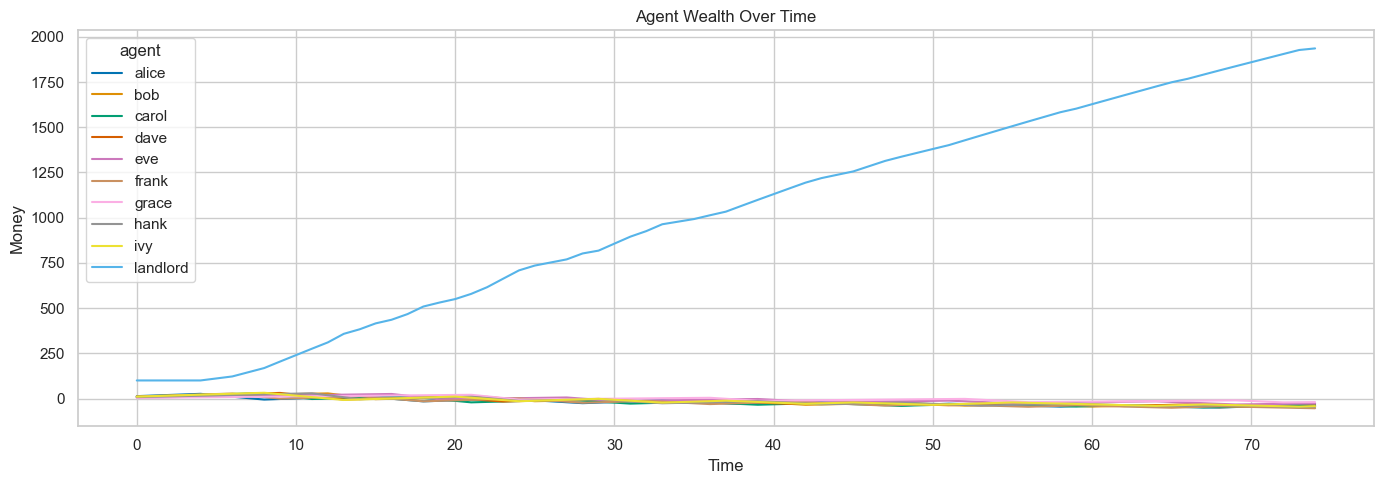

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=money_df, x="time", y="money", hue="agent", ax=ax)
ax.set_title("Agent Wealth Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Money")
sns.move_legend(ax, "upper left")
plt.tight_layout()
plt.show()

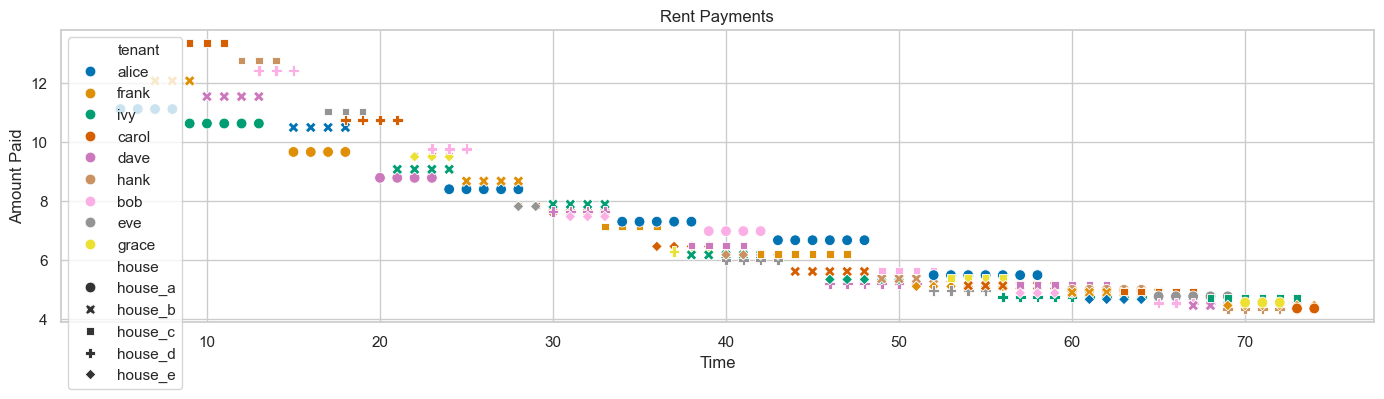

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.scatterplot(
    data=rent_df, x="time", y="amount",
    hue="tenant", style="house", s=60, ax=ax,
)
ax.set_title("Rent Payments")
ax.set_xlabel("Time")
ax.set_ylabel("Amount Paid")
sns.move_legend(ax, "upper left")
plt.tight_layout()
plt.show()

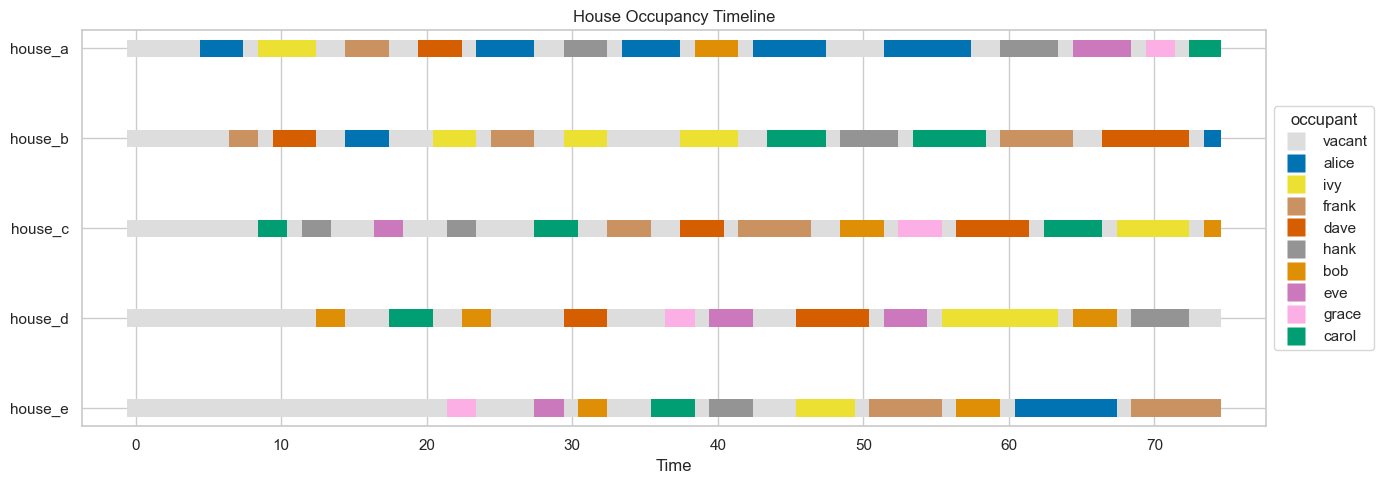

In [9]:
renter_names = sorted(
    occupancy_df.loc[occupancy_df["occupant"] != "vacant", "occupant"].unique()
)
palette = {"vacant": "#dddddd"}
palette.update({name: f"C{i}" for i, name in enumerate(renter_names)})

fig, ax = plt.subplots(figsize=(14, 5))
sns.scatterplot(
    data=occupancy_df, x="time", y="house", hue="occupant",
    palette=palette, s=160, marker="s", edgecolor="none", ax=ax,
)
ax.set_title("House Occupancy Timeline")
ax.set_xlabel("Time")
ax.set_ylabel("")
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()